In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

In [14]:
#matplotlib 한글

# 사용할 한글 폰트 지정 - 자기 OS만 # 지우고 쓰기
# font_path = "C:/Windows/Fonts/malgun.ttf"  # Windows
font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"  # macOS
# font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"  # Linux

font_prop = fm.FontProperties(fname=font_path)

# 폰트 적용
plt.rc('font', family=font_prop.get_name())

In [15]:
train = pd.read_csv('csv/train.csv')
test = pd.read_csv('csv/test.csv')
sample_submission = pd.read_csv('csv/sample_submission.csv')

In [16]:
#특성과 타겟 변수 분리
train = train.drop(columns=['ID'], axis = 1)
test = test.drop(columns=['ID'], axis = 1)

In [17]:
# 설립연도 타입 변환 (int -> object)
train['설립연도'] =train['설립연도'].astype('object')
test['설립연도'] =test['설립연도'].astype('object')

category_features = ['설립연도','국가','분야','투자단계','기업가치(백억원)']
numeric_features = ['직원 수','고객수(백만명)','총 투자금(억원)','연매출(억원)','SNS 팔로워 수(백만명)']
bool_features = ['인수여부','상장여부']

# LabelEncoder 객체를 각 범주형 feature별로 따로 저장하여 사용
encoders = {}

# 범주형 데이터를 encoding
for feature in category_features:
    encoders[feature] = LabelEncoder()
    train[feature] = train[feature].fillna('Missing')
    test[feature] = test[feature].fillna('Missing')
    train[feature] = encoders[feature].fit_transform(train[feature])
    test[feature] = encoders[feature].transform(test[feature])

# 불리언 값을 0과 1로 변환 ('Yes' → 1, 'No' → 0 으로 변환)
bool_map = {'Yes': 1, 'No': 0}

for feature in bool_features:
    train[feature] = train[feature].map(bool_map)
    test[feature] = test[feature].map(bool_map)

# 수치형 변수 결측치를 평균값으로 대체
for feature in numeric_features:
    mean_value = train[feature].mean()
    train[feature] = train[feature].fillna(mean_value)
    test[feature] = test[feature].fillna(mean_value)


/var/folders/ss/j3gw42tn6hj8yhjfpvq0shb00000gn/T/ipykernel_44124/3938303409.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train[feature] = train[feature].fillna('Missing')
/var/folders/ss/j3gw42tn6hj8yhjfpvq0shb00000gn/T/ipykernel_44124/3938303409.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test[feature] = test[feature].fillna('Missing')


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

# X: features, y: soft labels (확률 값)
X_train, X_test, y_train, y_test = train_test_split(train.drop(columns='성공확률',axis=1), train['성공확률'], test_size=0.2, random_state=42)

# 회귀 모델 예시
model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8
)
model.fit(X_train, y_train)

print("train score:",model.score(X_train, y_train))
print("test score:",model.score(X_test,y_test))

y_pred = model.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
print("train MSE:", mse)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("test MSE:", mse)

train score: 0.07991039828789137
test score: -0.007808421888887196
train MSE: 0.05384037698633314
test MSE: 0.05824651636539951


In [19]:
# 회귀 모델 파라미터 조정
model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8
)
model.fit(X_train, y_train)


print("train score:",model.score(X_train, y_train))
print("test score:",model.score(X_test,y_test))

y_pred = model.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
print("train MSE:", mse)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("test MSE:", mse)

train score: 0.2836676202049778
test score: -0.02094183069904143
train MSE: 0.041917227739466156
test MSE: 0.059005564706909076


In [20]:
# 회귀 모델 파라미터 조정
model = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=7,
    subsample=0.8
)
model.fit(X_train, y_train)


print("train score:",model.score(X_train, y_train))
print("test score:",model.score(X_test,y_test))

y_pred = model.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
print("train MSE:", mse)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("test MSE:", mse)

train score: 0.7666438019613783
test score: -0.031028091365469024
train MSE: 0.013655176247093396
test MSE: 0.059588502430203395


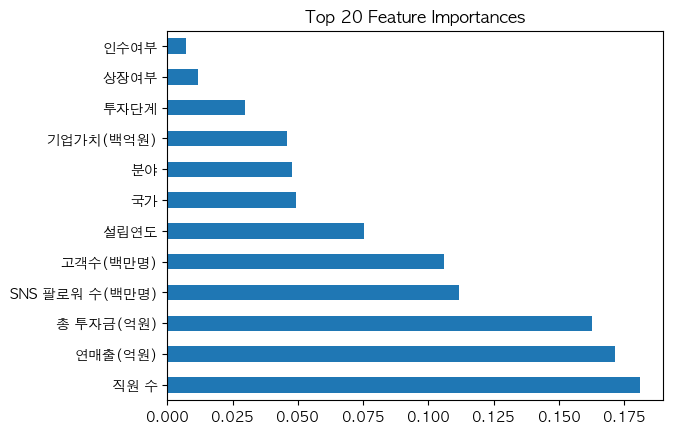

In [8]:
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp.nlargest(20).plot(kind='barh')
plt.title("Top 20 Feature Importances")
plt.show()

train score: 0.26465379613047746
test score: -0.010246609290141873
train MSE: 0.04302984922135008
test MSE: 0.05838743195936023


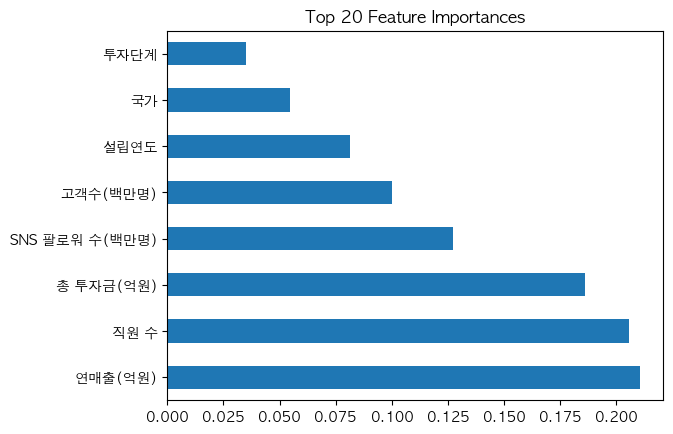

In [9]:
#직원수~투자금 로그 스케일, 인수, 상장 삭제, 고객수기업가치분야->고객수만 남기고 삭제
train_new=train.copy()
dropcol=['인수여부','상장여부','기업가치(백억원)','분야']
train_new.drop(columns=dropcol, inplace=True)
logcol=['직원 수','연매출(억원)','총 투자금(억원)']
for col in logcol:
    train_new[col]=np.log1p(train_new[col])


X_train, X_test, y_train, y_test = train_test_split(train_new.drop(columns='성공확률',axis=1), train_new['성공확률'], test_size=0.2, random_state=42)

# 회귀 모델 파라미터 조정
model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8
)
model.fit(X_train, y_train)


print("train score:",model.score(X_train, y_train))
print("test score:",model.score(X_test,y_test))

y_pred = model.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
print("train MSE:", mse)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("test MSE:", mse)

feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp.nlargest(20).plot(kind='barh')
plt.title("Top 20 Feature Importances")
plt.show()

In [10]:
# 회귀 모델 파라미터 조정
model = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=7,
    subsample=0.8
)
model.fit(X_train, y_train)


print("train score:",model.score(X_train, y_train))
print("test score:",model.score(X_test,y_test))

y_pred = model.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
print("train MSE:", mse)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("test MSE:", mse)


train score: 0.7250153760564414
test score: -0.016429167028425118
train MSE: 0.016091123941642742
test MSE: 0.05874475428636361


In [11]:
# 회귀 모델 파라미터 조정
model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8
)
model.fit(X_train, y_train)


print("train score:",model.score(X_train, y_train))
print("test score:",model.score(X_test,y_test))

y_pred = model.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
print("train MSE:", mse)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("test MSE:", mse)

train score: 0.8848652560962076
test score: -0.09530565649841694
train MSE: 0.006737276461412189
test MSE: 0.06330343888849096


In [12]:
#결측치 포함된 행 삭제
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(train.drop(columns=['성공확률','분야','직원 수','고객수(백만명)','기업가치(백억원)'],axis=1), train['성공확률'], test_size=0.2, random_state=42)

model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8
)
model.fit(X_train_2, y_train_2)

print("train score:",model.score(X_train_2, y_train_2))
print("test score:",model.score(X_test_2,y_test_2))

y_pred = model.predict(X_train_2)
mse = mean_squared_error(y_train_2, y_pred)
print("train MSE:", mse)

y_pred = model.predict(X_test_2)
mse = mean_squared_error(y_test_2, y_pred)
print("test MSE:", mse)

train score: 0.06310089053081125
test score: -0.008629270991747484
train MSE: 0.05482400970309443
test MSE: 0.05829395752550975
